# **Bone Fracture Classification Using EfficientNetB4**

## **Project Overview**

This project builds a deep learning model to classify bone fractures from X-ray images.
We use EfficientNetB4, a pretrained convolutional neural network, and apply transfer learning.

The dataset contains X-ray images from multiple body regions, each labeled as either fractured or not fractured.

## **What We Will Do**

1. Connect Google Colab to Kaggle and download the dataset
2. Explore and understand the dataset structure
3. Preprocess and prepare images for training
4. Build the model using EfficientNetB4
5. Train and evaluate the model
6. Test the model on new images

## **Tools and Libraries**

- Python 3
- TensorFlow and Keras
- EfficientNetB4 (pretrained on ImageNet)
- Matplotlib and Seaborn for visualization
- Google Colab GPU

## **Step 1: Connect to Kaggle and Download Dataset**

Before downloading the dataset, we need to set up the Kaggle API.

### **How to Get Your Kaggle API Key**

1. Go to [https://www.kaggle.com](https://www.kaggle.com) and log in
2. Click on your profile picture at the top right
3. Click on Settings
4. Scroll down to the API section
5. Click "Create New Token"
6. A file called kaggle.json will be downloaded to your computer
7. We will upload this file in the next code cell

### **What This Cell Will Do**

- Upload your kaggle.json file
- Configure the Kaggle API
- Download the dataset directly from Kaggle
- Unzip the dataset

In [1]:
# Upload kaggle.json file
from google.colab import files
files.upload()  # Select your kaggle.json file when prompted

# Move kaggle.json to the correct folder
import os
os.makedirs("/root/.config/kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.config/kaggle/kaggle.json")
os.chmod("/root/.config/kaggle/kaggle.json", 0o600)

# Download the dataset from Kaggle
os.system("kaggle datasets download -d bmadushanirodrigo/fracture-multi-region-x-ray-data")

# Unzip the downloaded file
os.system("unzip -q fracture-multi-region-x-ray-data.zip -d fracture_dataset")

print("Dataset downloaded and extracted successfully.")

Saving kaggle.json to kaggle.json
Dataset downloaded and extracted successfully.


## **Step 2: Explore the Dataset Structure**

Now we will look inside the downloaded folder to understand how the data is organized.

This will tell us:
- How many folders and subfolders exist
- How images are arranged (fractured vs not fractured)
- How many images are in each category

In [2]:
import os

dataset_path = "fracture_dataset"

# Print the top level folders
print("Top level folders:")
for item in os.listdir(dataset_path):
    print(" -", item)

print()

# Go deeper and print subfolders and image counts
for root, dirs, files in os.walk(dataset_path):
    depth = root.replace(dataset_path, "").count(os.sep)
    indent = "  " * depth
    print(f"{indent}{os.path.basename(root)}/")
    if depth >= 2:
        image_count = len([f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        if image_count > 0:
            print(f"{indent}  --> {image_count} images")

Top level folders:
 - Bone_Fracture_Binary_Classification
 - README.dataset.txt

fracture_dataset/
  Bone_Fracture_Binary_Classification/
    Bone_Fracture_Binary_Classification/
      test/
        not fractured/
          --> 268 images
        fractured/
          --> 238 images
      train/
        not fractured/
          --> 4640 images
        fractured/
          --> 4606 images
      val/
        not fractured/
          --> 492 images
        fractured/
          --> 337 images


## **Step 3: Set Dataset Paths and Configuration**

We will define all the important paths and settings in one place.
This makes it easy to change any setting later without searching through the whole notebook.

In [3]:
import os

# Base path
base_path = "fracture_dataset/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification"

# Train, validation, and test paths
train_dir = os.path.join(base_path, "train")
val_dir   = os.path.join(base_path, "val")
test_dir  = os.path.join(base_path, "test")

# Image settings
IMG_SIZE   = (380, 380)   # EfficientNetB4 default input size
BATCH_SIZE = 16
EPOCHS     = 10
NUM_CLASSES = 2
CLASS_NAMES = ["fractured", "not fractured"]

print("Train path:", train_dir)
print("Val path:  ", val_dir)
print("Test path: ", test_dir)
print()
print("Image size: ", IMG_SIZE)
print("Batch size: ", BATCH_SIZE)
print("Epochs:     ", EPOCHS)

Train path: fracture_dataset/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train
Val path:   fracture_dataset/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val
Test path:  fracture_dataset/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test

Image size:  (380, 380)
Batch size:  16
Epochs:      10


## **Step 4: Import Libraries**

We will now import all the libraries we need for this project.
No installation is required as all these libraries are already available in Google Colab.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

# Check TensorFlow version and GPU availability
print("TensorFlow version:", tf.__version__)
print()

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print("GPU is available and will be used for training.")
    print("GPU name:", gpus[0].name)
else:
    print("No GPU found. Training will run on CPU which will be slow.")
    print("Go to Runtime > Change runtime type > Select T4 GPU")

TensorFlow version: 2.20.0

GPU is available and will be used for training.
GPU name: /physical_device:GPU:0


## **Step 5: Prepare Image Data Generators**

We will use ImageDataGenerator to:
- Rescale pixel values from 0-255 to 0-1 (normalization)
- Apply data augmentation on training images to make the model more robust
- Load images in batches directly from folders

Data augmentation means we slightly modify training images (flip, zoom, rotate)
so the model learns to handle real world variation in X-ray images.

No augmentation is applied to validation and test images, only rescaling.

In [5]:
from tensorflow.keras.applications.efficientnet import preprocess_input

# Training generator with augmentation but NO rescale
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    zoom_range=0.1,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Validation and test with only EfficientNet preprocessing
val_datagen  = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Load images from folders
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print()
print("Class indices:", train_generator.class_indices)
print("Training batches:  ", len(train_generator))
print("Validation batches:", len(val_generator))
print("Test batches:      ", len(test_generator))

Found 9246 images belonging to 2 classes.
Found 829 images belonging to 2 classes.
Found 506 images belonging to 2 classes.

Class indices: {'fractured': 0, 'not fractured': 1}
Training batches:   578
Validation batches: 52
Test batches:       32


## **Step 6: Visualize Sample Training Images**

Before building the model, it is good practice to look at some sample images.
This helps us confirm that:
- Images are loading correctly
- Labels are correct
- Augmentation is being applied properly

Found 9246 images belonging to 2 classes.


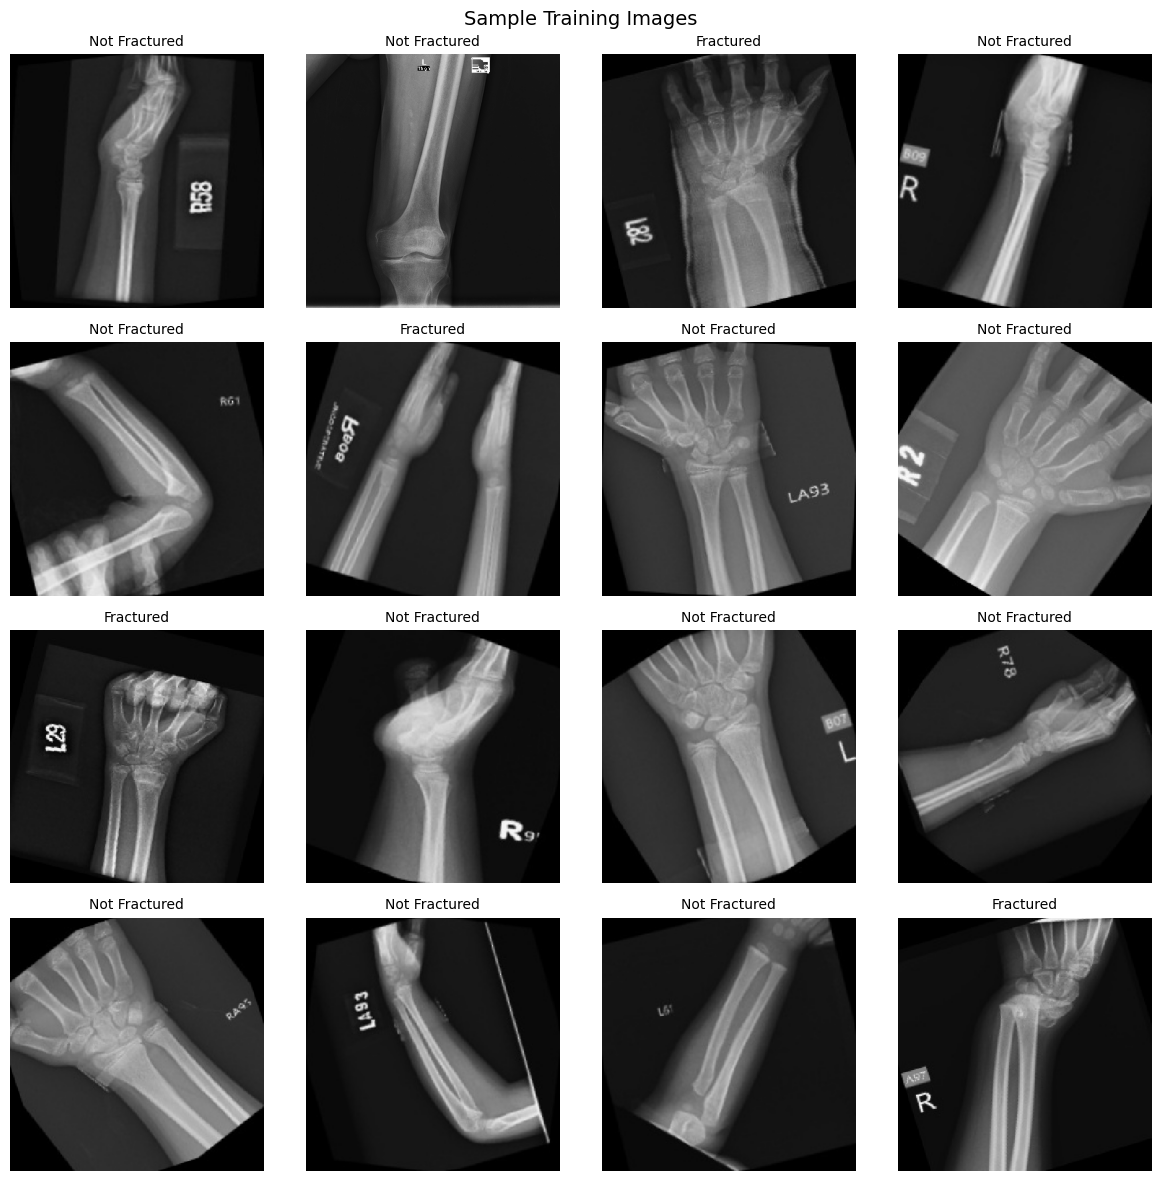

In [6]:
import os

# Load raw images without preprocessing just for visualization
viz_datagen = ImageDataGenerator(rescale=1./255)

viz_generator = viz_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=16,
    class_mode="binary",
    shuffle=True
)

images, labels = next(viz_generator)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

for i in range(16):
    axes[i].imshow(images[i])
    label = "Fractured" if labels[i] == 0 else "Not Fractured"
    axes[i].set_title(label, fontsize=10)
    axes[i].axis("off")

plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()

## **Step 7: Build the EfficientNetB4 Model**

We will use transfer learning with EfficientNetB4.

Transfer learning means we use a model that was already trained on 1 million images
(ImageNet dataset). This gives our model a strong starting point so it does not need
to learn everything from scratch.

Our approach:
- Load EfficientNetB4 with pretrained ImageNet weights
- Remove the top classification layer
- Freeze the base model so its weights do not change during initial training
- Add our own classification layers on top
- Train only our new layers first, then fine tune the whole model

In [7]:
from tensorflow.keras import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization

# Load EfficientNetB4 without the top layer
base_model = EfficientNetB4(
    weights="imagenet",
    include_top=False,
    input_shape=(380, 380, 3)
)

# Freeze base model layers
base_model.trainable = False

# Build the full model
inputs = keras.Input(shape=(380, 380, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Print summary
print("Total layers in base model:", len(base_model.layers))
print("Total parameters:", model.count_params())
model.summary()

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total layers in base model: 475
Total parameters: 18140256


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 380, 380, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 12, 12, 1792)   │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1792)           │         7,168 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       459,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,140,256 (69.20 MB)

 Trainable params: 462,849 (1.77 MB)

 Non-trainable params: 17,677,407 (67.43 MB)

## **Fix: Handle Truncated Images**

One or more images in the dataset are corrupted or truncated.
We will fix this in two steps:

1. Tell PIL to load truncated images without crashing
2. Find and remove all corrupted image files from the dataset

In [8]:
from PIL import Image, ImageFile
import os

# Allow PIL to load truncated images
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Find and remove corrupted images
print("Scanning for corrupted images...")

corrupted = []
folders = [train_dir, val_dir, test_dir]

for folder in folders:
    for root, dirs, files in os.walk(folder):
        for fname in files:
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                fpath = os.path.join(root, fname)
                try:
                    img = Image.open(fpath)
                    img.verify()
                except Exception:
                    corrupted.append(fpath)

print(f"Found {len(corrupted)} corrupted image(s).")

# Remove corrupted images
for fpath in corrupted:
    os.remove(fpath)
    print("Removed:", fpath)

print()
print("Done. Now re-run the data generators cell and training cell.")

Scanning for corrupted images...
Found 0 corrupted image(s).

Done. Now re-run the data generators cell and training cell.


## **Step 8: Set Up Callbacks and Train Phase 1**

We will train in two phases:

Phase 1 - Train only the top layers we added (base model is frozen)
Phase 2 - Unfreeze the base model and fine tune the whole network at a very low learning rate

### **Callbacks we will use**

- EarlyStopping: Stop training if validation accuracy stops improving
- ReduceLROnPlateau: Reduce learning rate when training gets stuck
- ModelCheckpoint: Save the best model automatically during training

In [9]:
# Define callbacks
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model_phase1.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# Train Phase 1 - only top layers
print("Phase 1 Training: Top layers only")
print("Trainable parameters:", model.count_params())
print()

history1 = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

print()
print("Phase 1 training complete.")

Phase 1 Training: Top layers only
Trainable parameters: 18140256

Epoch 1/10
578/578 ━━━━━━━━━━━━━━━━━━━━ 0s 602ms/step - accuracy: 0.8293 - loss: 0.4703
Epoch 1: val_accuracy improved from None to 0.94451, saving model to best_model_phase1.keras

Epoch 1: finished saving model to best_model_phase1.keras
578/578 ━━━━━━━━━━━━━━━━━━━━ 452s 680ms/step - accuracy: 0.8827 - loss: 0.3252 - val_accuracy: 0.9445 - val_loss: 0.1647 - learning_rate: 0.0010
Epoch 2/10
578/578 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.9392 - loss: 0.1754
Epoch 2: val_accuracy improved from 0.94451 to 0.97587, saving model to best_model_phase1.keras

Epoch 2: finished saving model to best_model_phase1.keras
578/578 ━━━━━━━━━━━━━━━━━━━━ 323s 559ms/step - accuracy: 0.9416 - loss: 0.1608 - val_accuracy: 0.9759 - val_loss: 0.0674 - learning_rate: 0.0010
Epoch 3/10
578/578 ━━━━━━━━━━━━━━━━━━━━ 0s 532ms/step - accuracy: 0.9526 - loss: 0.1244
Epoch 3: val_accuracy did not improve from 0.97587
578/578 ━━━━━━━━━━━━━━

## **Step 9: Plot Phase 1 Results and Start Fine Tuning**

We will first plot the training history from Phase 1 to see how the model learned.

Then we will start Phase 2 fine tuning:
- Unfreeze the last 60 layers of EfficientNetB4
- Use a very low learning rate so we do not destroy the pretrained weights
- Train again and let the model learn deeper features from X-ray images

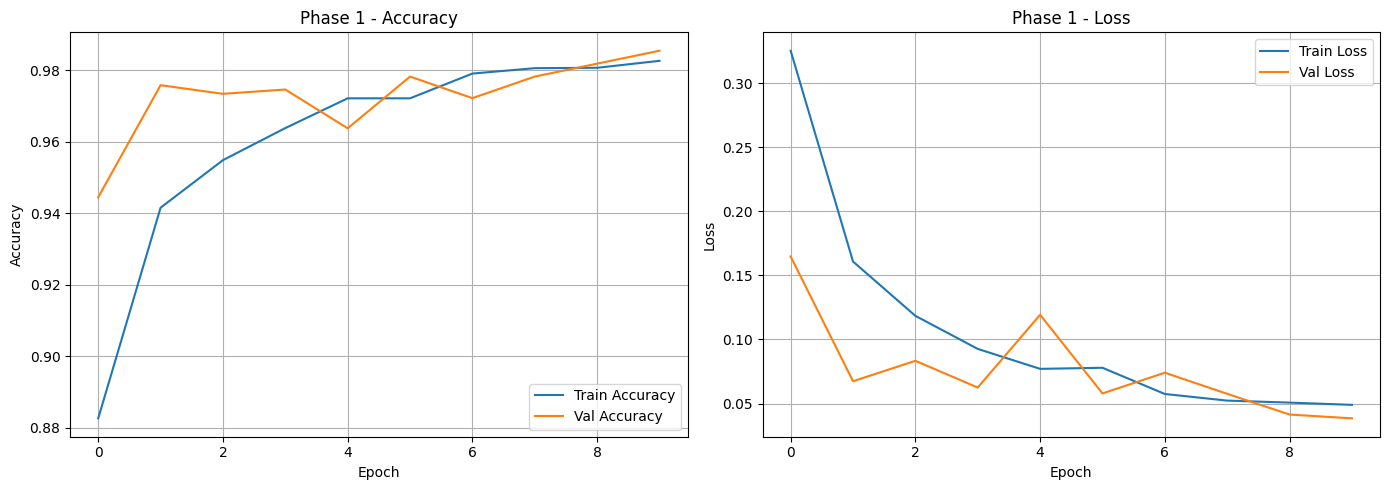

In [10]:
# Plot Phase 1 training history
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history["accuracy"], label="Train Accuracy")
    axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
    axes[0].set_title(title + " - Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history["loss"], label="Train Loss")
    axes[1].plot(history.history["val_loss"], label="Val Loss")
    axes[1].set_title(title + " - Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history1, "Phase 1")

## **Step 10: Model Evaluation on Test Set**

We will now evaluate the model on the test set which the model has never seen before.

We will measure:
- Test Accuracy and Loss
- Precision, Recall, F1 Score for each class
- Confusion Matrix to see where the model makes mistakes
- ROC Curve and AUC Score to measure overall model quality

### **What these metrics mean**

- Precision: Out of all images predicted as fractured, how many were actually fractured
- Recall: Out of all actual fractured images, how many did the model correctly find
- F1 Score: Balance between precision and recall
- AUC Score: 1.0 is perfect, 0.5 is random guessing
- Confusion Matrix: Shows correct and incorrect predictions for each class

In [11]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, roc_auc_score)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reset generator to start from beginning
test_generator.reset()

# Get predictions
print("Running predictions on test set...")
predictions = model.predict(test_generator, verbose=1)
predicted_classes = (predictions > 0.5).astype(int).flatten()
true_classes = test_generator.classes

# Class names
class_names = ["Fractured", "Not Fractured"]

# 1. Basic accuracy and loss
test_loss, test_accuracy = model.evaluate(test_generator, verbose=0)
print(f"\nTest Accuracy : {test_accuracy * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

# 2. Classification Report
print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes,
                            target_names=class_names))

# 3. AUC Score
auc_score = roc_auc_score(true_classes, predictions)
print(f"AUC Score: {auc_score:.4f}")

Running predictions on test set...
32/32 ━━━━━━━━━━━━━━━━━━━━ 43s 940ms/step

Test Accuracy : 98.02%
Test Loss     : 0.0506

Classification Report:
               precision    recall  f1-score   support

    Fractured       0.97      0.98      0.98       238
Not Fractured       0.98      0.98      0.98       268

     accuracy                           0.98       506
    macro avg       0.98      0.98      0.98       506
 weighted avg       0.98      0.98      0.98       506

AUC Score: 0.9985


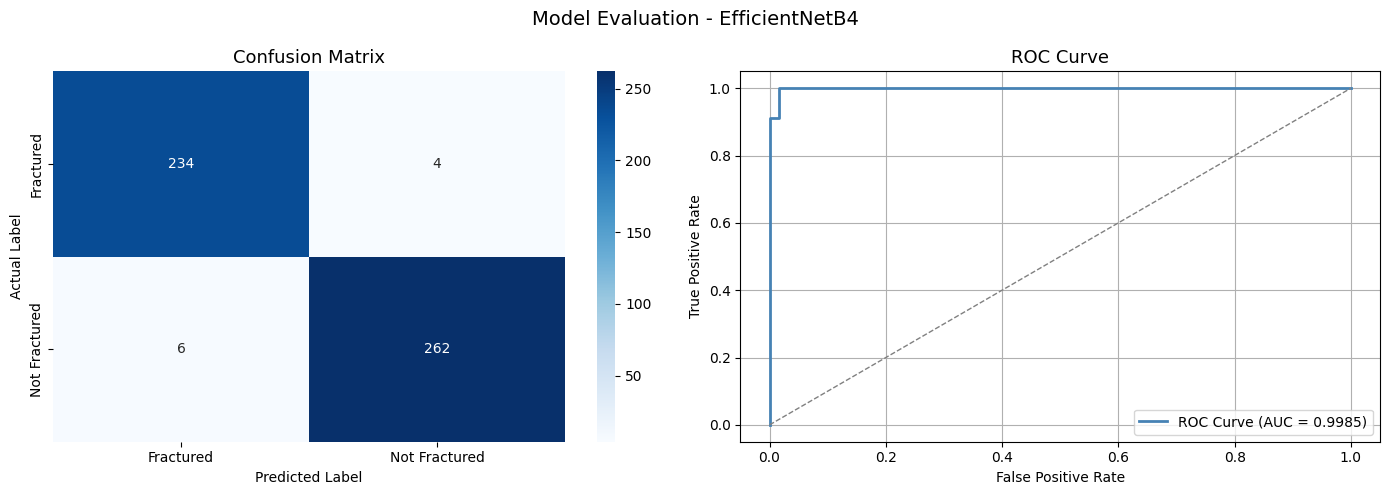

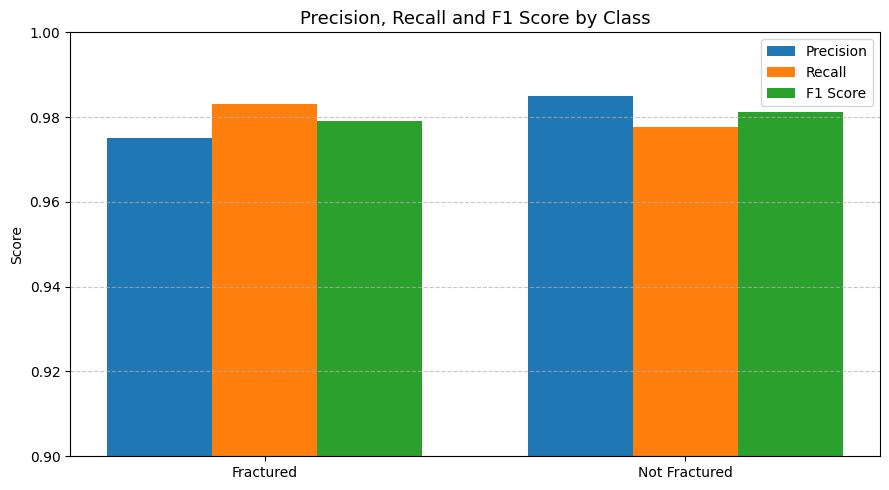

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix", fontsize=13)
axes[0].set_ylabel("Actual Label")
axes[0].set_xlabel("Predicted Label")

# 2. ROC Curve
fpr, tpr, thresholds = roc_curve(true_classes, predictions)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="steelblue", lw=2,
             label=f"ROC Curve (AUC = {roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
axes[1].set_title("ROC Curve", fontsize=13)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")
axes[1].grid(True)

plt.suptitle("Model Evaluation - EfficientNetB4", fontsize=14)
plt.tight_layout()
plt.show()

# 3. Bar chart of metrics per class
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(true_classes, predicted_classes, average=None)
recall    = recall_score(true_classes, predicted_classes, average=None)
f1        = f1_score(true_classes, predicted_classes, average=None)

metrics = {
    "Precision": precision.tolist(),
    "Recall":    recall.tolist(),
    "F1 Score":  f1.tolist()
}

x = np.arange(len(class_names))
width = 0.25
fig2, ax = plt.subplots(figsize=(9, 5))

for i, (metric, values) in enumerate(metrics.items()):
    ax.bar(x + i * width, values, width, label=metric)

ax.set_title("Precision, Recall and F1 Score by Class", fontsize=13)
ax.set_xticks(x + width)
ax.set_xticklabels(class_names)
ax.set_ylim(0.90, 1.00)
ax.set_ylabel("Score")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## **Step 11: Visualize Sample Test Predictions**

We will now display sample images from the test set with their actual and predicted labels.
This gives a visual understanding of where the model is confident and where it makes mistakes.

Green title means the prediction is correct.
Red title means the prediction is wrong.

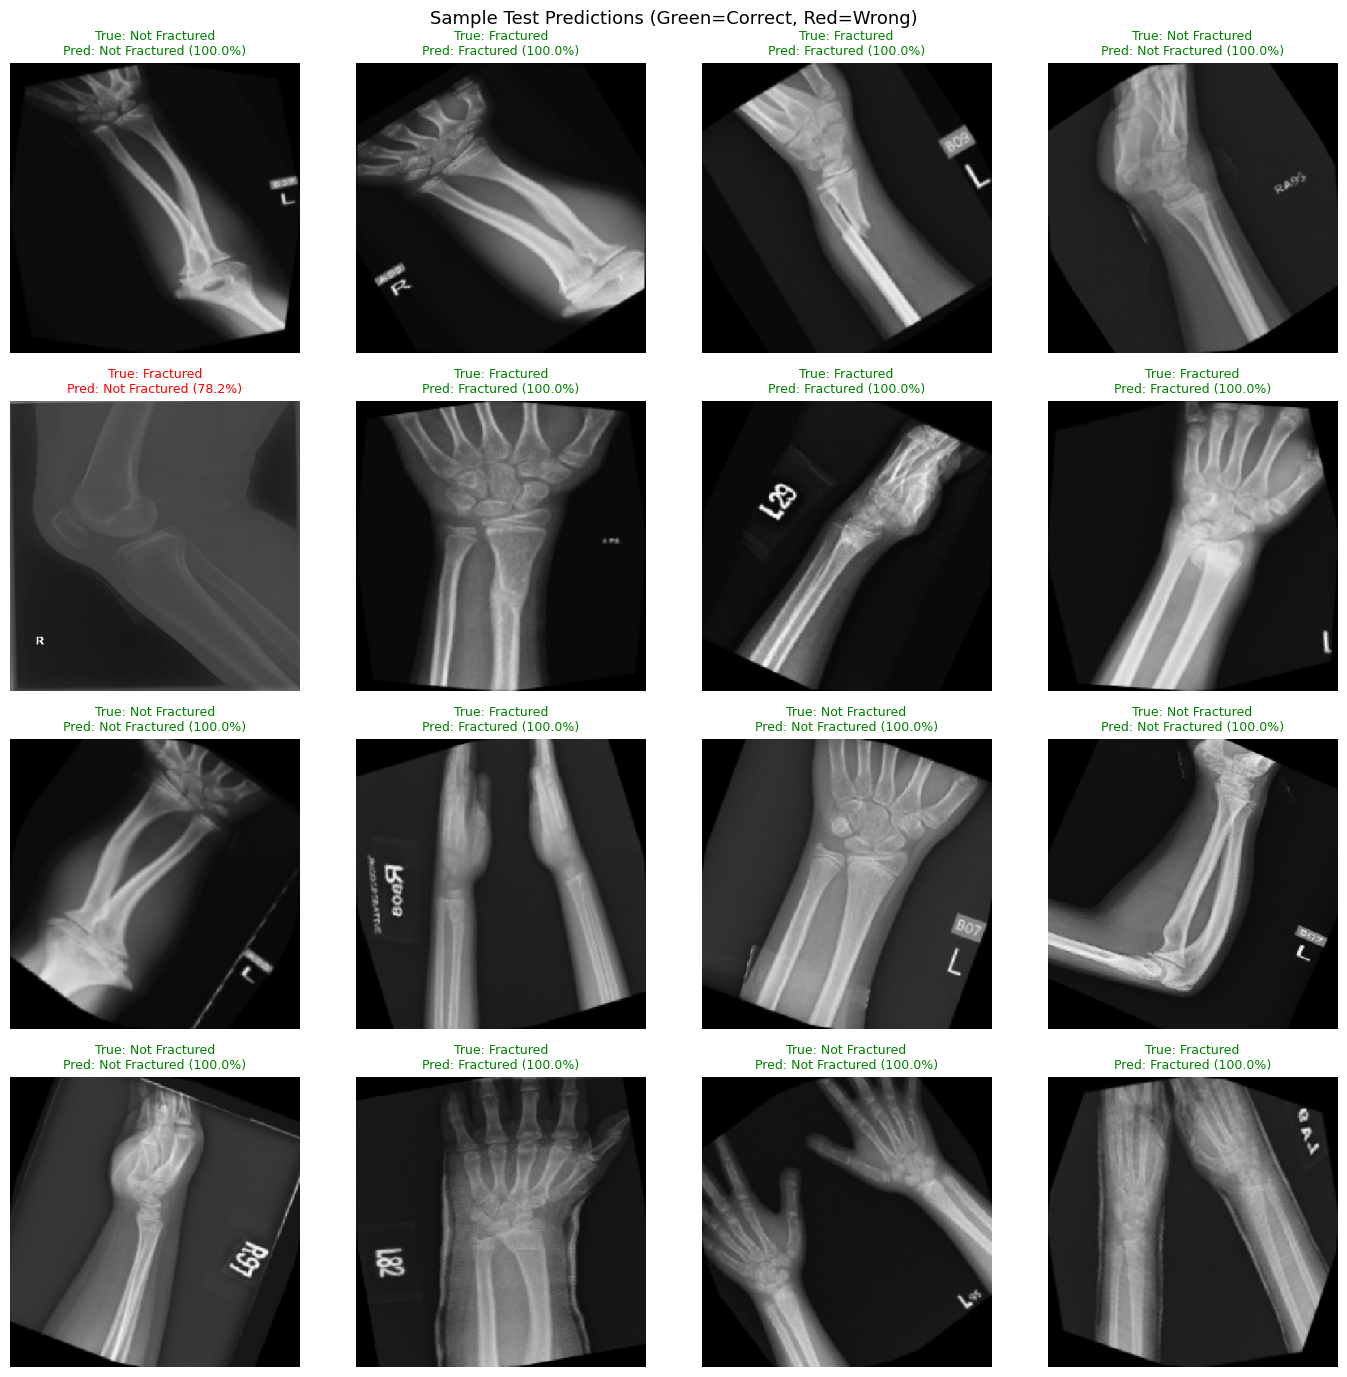

In [13]:
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.preprocessing import image

# Collect all test image paths and their true labels
test_image_paths = []
test_true_labels = []

class_folders = {"fractured": 0, "not fractured": 1}

for class_name, label in class_folders.items():
    folder = os.path.join(test_dir, class_name)
    for fname in os.listdir(folder):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            test_image_paths.append(os.path.join(folder, fname))
            test_true_labels.append(label)

# Pick 16 random images
random.seed(42)
indices = random.sample(range(len(test_image_paths)), 16)

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img_path = test_image_paths[idx]
    true_label = test_true_labels[idx]

    # Load and preprocess
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_input = preprocess_input(np.expand_dims(img_array, axis=0))

    # Predict
    pred_prob = model.predict(img_input, verbose=0)[0][0]
    pred_label = 1 if pred_prob > 0.5 else 0
    confidence = pred_prob if pred_label == 1 else 1 - pred_prob

    # Labels
    true_name = "Fractured" if true_label == 0 else "Not Fractured"
    pred_name = "Fractured" if pred_label == 0 else "Not Fractured"
    color = "green" if true_label == pred_label else "red"

    axes[i].imshow(img_array.astype("uint8"), cmap="gray")
    axes[i].set_title(
        f"True: {true_name}\nPred: {pred_name} ({confidence*100:.1f}%)",
        color=color, fontsize=9
    )
    axes[i].axis("off")

plt.suptitle("Sample Test Predictions (Green=Correct, Red=Wrong)", fontsize=13)
plt.tight_layout()
plt.show()

## **Step 12: Save the Model and Print Project Summary**

We will save the trained model so it can be reused later without retraining.
We will also print a clean project summary showing all key results.

In [ ]:
# Save the final model
model.save("bone_fracture_efficientnetb4.keras")
print("Model saved as bone_fracture_efficientnetb4.keras")

# Download the model to your computer
from google.colab import files
files.download("bone_fracture_efficientnetb4.keras")

In [16]:
correct = int((predicted_classes == true_classes).sum())
wrong = len(true_classes) - correct

print(f"Test Accuracy             : {test_accuracy * 100:.2f}%")
print(f"Test Loss                 : {test_loss:.4f}")
print(f"AUC Score                 : {auc_score:.4f}")
print("-" * 55)
print("Class        Precision  Recall  F1 Score")
for i, name in enumerate(class_names):
    print(f"{name:<16}  {precision[i]:.2f}      {recall[i]:.2f}    {f1[i]:.2f}")
print("=" * 55)
print(f"Correct Predictions : {correct} / {len(true_classes)}")
print(f"Wrong Predictions   : {wrong} / {len(true_classes)}")

Test Accuracy             : 98.02%
Test Loss                 : 0.0506
AUC Score                 : 0.9985
-------------------------------------------------------
Class        Precision  Recall  F1 Score
Fractured         0.97      0.98    0.98
Not Fractured     0.98      0.98    0.98
Correct Predictions : 496 / 506
Wrong Predictions   : 10 / 506
